In [ ]:
# DEHYDRATION PREDICTION PROJECT - COMPLETE EDA

# ── CELL 1: Upload your files ────────────────────────────────
from google.colab import files

print("Upload diagnosis.csv")
files.upload()
print("Upload medication.csv")
files.upload()
print("Upload notes.csv")
files.upload()


In [ ]:
# ── CELL 2: Install & import libraries ──────────────────────
!pip install wordcloud -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

sns.set_theme(style="whitegrid")

In [ ]:
# ── CELL 3: Load the data ────────────────────────────────────
diag  = pd.read_csv("diagnosis.csv")
med   = pd.read_csv("medication.csv")
notes = pd.read_csv("notes.csv", encoding="latin1", low_memory=False)

notes["target"] = pd.to_numeric(notes["target"], errors="coerce")
notes["note"]   = notes["note"].fillna("").astype(str)

# Convert dates
diag["date_of_target"]      = pd.to_datetime(diag["date_of_target"])
diag["date_of_diagnosis"]   = pd.to_datetime(diag["date_of_diagnosis"])
med["date_of_target"]       = pd.to_datetime(med["date_of_target"])
med["date_of_prescription"] = pd.to_datetime(med["date_of_prescription"])
notes["date_of_target"]     = pd.to_datetime(notes["date_of_target"])
notes["date_of_note"]       = pd.to_datetime(notes["date_of_note"], errors="coerce")

print("Data loaded successfully.")
print(f"Diagnosis: {diag.shape} | Medication: {med.shape} | Notes: {notes.shape}")

In [ ]:
# ── CELL 4: Missing values ───────────────────────────────────
print("=== MISSING VALUES ===")
for name, df in [("Diagnosis", diag), ("Medication", med), ("Notes", notes)]:
    print(f"\n{name}:")
    print(df.isnull().sum())

# Check if missing diagnoses are spread randomly across months
diag["month"] = diag["date_of_diagnosis"].dt.month
missing_by_month = diag[diag["diagnosis"].isnull()]["month"].value_counts().sort_index()
total_by_month   = diag["month"].value_counts().sort_index()
missing_pct      = (missing_by_month / total_by_month * 100).round(1)

print("\n=== MISSING DIAGNOSIS BY MONTH (%) ===")
print(missing_pct)
print("\n→ Similar % across all months = missingness is random, safe to fill with UNKNOWN")

# Fill missing diagnosis with UNKNOWN
diag["diagnosis"] = diag["diagnosis"].fillna("UNKNOWN")
print(f"\nMissing diagnoses after filling: {diag['diagnosis'].isnull().sum()}")


In [ ]:
# ── CELL 5: Outlier checks ───────────────────────────────────
# Short/useless notes
notes["note_length"] = notes["note"].apply(len)
short_notes = notes[notes["note_length"] < 10]
print(f"=== SHORT NOTES (under 10 chars): {len(short_notes)} ===")
print(short_notes["note"].value_counts().head(10))

# Notes per assessment
notes_per = notes.groupby(["resident_id", "date_of_target"]).size()
print(f"\n=== NOTES PER ASSESSMENT ===")
print(notes_per.describe())
print(f"Assessments with >100 notes: {(notes_per > 100).sum()}")

# Plot note length distribution
plt.figure(figsize=(8, 4))
notes["note_length"].hist(bins=40, color="mediumpurple", edgecolor="black")
plt.title("Distribution of Individual Note Lengths (characters)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot_note_lengths.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# EDA CORRECTIONS — Add these cells to your existing notebook
# Add them right after Cell 5 (Outlier checks)
# ============================================================

# ── CORRECTION CELL 1: Fix binary target values ─────────────

print("=== TARGET VALUE CHECK BEFORE FIXING ===")
print("Notes target unique values:", notes["target"].unique())
print("Notes target value counts:")
print(notes["target"].value_counts())

# Convert target to numeric — '-' becomes NaN, then drop those rows
notes["target"] = pd.to_numeric(notes["target"], errors="coerce")

# How many rows dropped?
before = len(notes)
notes = notes.dropna(subset=["target"])
notes["target"] = notes["target"].astype(int)
after = len(notes)

print(f"\n=== TARGET AFTER FIXING ===")
print(f"Rows removed (invalid '-' target): {before - after}")
print("Notes target unique values:", notes["target"].unique())
print("Notes target value counts:")
print(notes["target"].value_counts())

# ── CORRECTION CELL 2: Note length distribution & truncation ─

notes["note_length"] = notes["note"].fillna("").astype(str).apply(len)

# Flag truncated notes (exactly 255 chars = hit database limit)
notes["is_truncated"] = (notes["note_length"] == 255).astype(int)

truncated_count = notes["is_truncated"].sum()
print(f"=== TRUNCATED NOTES (exactly 255 chars): {truncated_count} ({truncated_count/len(notes)*100:.1f}%) ===")
print("These notes were cut off by the database — they continue in the next row.")
print("This is handled by joining all notes per patient per assessment.")

# Plot note length distribution — full vs non-truncated
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

notes["note_length"].hist(bins=30, ax=axes[0], color="mediumpurple", edgecolor="black")
axes[0].set_title("Note Length Distribution (All Notes)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].axvline(x=255, color="red", linestyle="--", label="255-char truncation limit")
axes[0].legend()

notes[notes["note_length"] < 255]["note_length"].hist(
    bins=30, ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Note Length Distribution (Excluding Truncated)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("plot_note_length_corrected.png", dpi=150)
plt.show()

print("\n=== NOTE LENGTH STATS (excluding truncated) ===")
print(notes[notes["note_length"] < 255]["note_length"].describe())

# ── CORRECTION CELL 3: Document class imbalance ─────────────

print("=== CLASS IMBALANCE ACROSS ALL FILES ===")

# Get unique assessments per file
diag_target  = diag[["resident_id","date_of_target","target"]].drop_duplicates()
med_target   = med[["resident_id","date_of_target","target"]].drop_duplicates()
notes_target = notes[["resident_id","date_of_target","target"]].drop_duplicates()

for name, df in [("Diagnosis", diag_target), ("Medication", med_target), ("Notes", notes_target)]:
    total = len(df)
    pos   = (df["target"] == 1).sum()
    neg   = (df["target"] == 0).sum()
    print(f"\n{name}:")
    print(f"  Dehydrated (1):     {pos} ({pos/total*100:.2f}%)")
    print(f"  Not dehydrated (0): {neg} ({neg/total*100:.2f}%)")
    print(f"  Imbalance ratio:    1 : {neg//pos if pos > 0 else 'N/A'}")

# Visualize imbalance
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [("Diagnosis", diag_target), ("Medication", med_target), ("Notes", notes_target)]):
    counts = df["target"].value_counts().rename({0: "Not Dehydrated", 1: "Dehydrated"})
    counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
    ax.set_title(f"Class Balance — {name}")
    ax.set_ylabel("Assessments")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("plot_class_imbalance.png", dpi=150)
plt.show()

print("\n→ CONCLUSION: Dehydration target is too imbalanced for traditional ML prediction.")
print("→ Project pivots to Option B: Patient Risk Dashboard using NLP on nursing notes.")
print("→ Target label will not be used as prediction outcome going forward.")

In [ ]:
# ── FIX: Replace existing icd10_names dictionary with this ──
# Covers the top codes in the dataset

icd10_names = {
    # Already in dictionary
    "M62":"Muscle Disorder","R41":"Cognitive/Memory Symptoms","R26":"Abnormal Gait/Mobility",
    "I10":"Hypertension","R27":"Coordination Disorder","E78":"Lipid Disorder",
    "E11":"Type 2 Diabetes","K21":"Gastroesophageal Reflux","R13":"Swallowing Difficulty",
    "R53":"Fatigue/Malaise","F33":"Depression","K59":"Bowel Disorder",
    "E87":"Fluid/Electrolyte Disorder","Z74":"Dependence on Care","F41":"Anxiety Disorder",
    "I50":"Heart Failure","G47":"Sleep Disorder","J44":"COPD","I69":"Stroke Sequelae",
    "I25":"Coronary Artery Disease","Z93":"Feeding Tube Dependence","J96":"Respiratory Failure",
    "N39":"Urinary Tract Infection","F03":"Dementia","G20":"Parkinson's Disease",
    "M24":"Joint Disorder","I48":"Atrial Fibrillation","N18":"Chronic Kidney Disease",
    "Z87":"Personal History of Disease","E03":"Hypothyroidism","G30":"Alzheimer's Disease",

    # New additions - top unmatched codes
    "D64":"Anemia","E55":"Vitamin D Deficiency","F32":"Depressive Episode",
    "E56":"Vitamin Deficiency","M25":"Joint Pain/Disorder","R29":"Nervous System Symptoms",
    "I63":"Stroke","F02":"Dementia in Other Diseases","R47":"Speech Disturbance",
    "J18":"Pneumonia","R52":"Pain (Unspecified)","G93":"Brain Disorder",
    "L89":"Pressure Ulcer","N17":"Acute Kidney Failure","G40":"Epilepsy/Seizures",
    "R60":"Edema","R06":"Breathing Abnormality","M19":"Osteoarthritis",
    "E66":"Obesity","R63":"Eating/Feeding Difficulty","G89":"Pain Disorder",
    "N40":"Enlarged Prostate","F20":"Schizophrenia","J30":"Allergic Rhinitis",
    "Z91":"Personal Risk Factors","S72":"Hip Fracture","Z86":"Personal History - Disease",
    "L03":"Cellulitis","A41":"Sepsis","I73":"Peripheral Vascular Disease",
    "F31":"Bipolar Disorder","M54":"Back Pain","F10":"Alcohol Use Disorder",
    "Z89":"Acquired Absence of Limb","F29":"Psychosis","F25":"Schizoaffective Disorder",
    "M79":"Soft Tissue Disorder","D50":"Iron Deficiency Anemia","Z51":"Medical Care/Treatment",
    "I11":"Hypertensive Heart Disease","F06":"Mental Disorder due to Brain Damage",
    "Z43":"Artificial Opening Status","R45":"Behavioral Symptoms","R00":"Heart Rate Abnormality",
    "UNKNOWN":"Unknown/Missing"
}

diag["diagnosis_name"] = diag["diagnosis"].map(icd10_names).fillna(diag["diagnosis"])

# Check coverage
total = len(diag)
matched = diag["diagnosis_name"].isin(icd10_names.values()).sum()
still_code = (~diag["diagnosis"].isin(icd10_names.keys())).sum()
print(f"=== ICD-10 NAME COVERAGE ===")
print(f"Total diagnosis rows:      {total}")
print(f"Still showing raw codes:   {still_code} ({still_code/total*100:.1f}%)")
print(f"\nTop remaining unmatched codes:")
unmatched = diag[~diag["diagnosis"].isin(icd10_names.keys())]["diagnosis"].value_counts().head(10)
print(unmatched)

In [ ]:
# ── CELL 7: Target distribution ─────────────────────────────
target = diag[["resident_id", "date_of_target", "target"]].drop_duplicates()
counts = target["target"].value_counts().rename({0: "Not Dehydrated", 1: "Dehydrated"})

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("Dehydration Status (Target Variable)")
plt.xticks(rotation=0)
plt.ylabel("Number of Assessments")
plt.tight_layout()
plt.savefig("plot_target.png", dpi=150)
plt.show()

print(counts)
print(f"\nDehydration rate: {counts['Dehydrated'] / counts.sum() * 100:.2f}%")
print(f"Unique patients ever dehydrated: {diag[diag['target']==1]['resident_id'].nunique()}")

In [ ]:
# ── CELL 8: Top diagnoses & medications charts ───────────────
# Top diagnoses using readable names
top_diag = diag.groupby("diagnosis_name").size().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
top_diag.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 15 Most Common Diagnoses")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot_top_diagnoses.png", dpi=150)
plt.show()

# Top medications
top_med = med["medication"].value_counts().head(15)

plt.figure(figsize=(12, 5))
top_med.plot(kind="bar", color="teal", edgecolor="black")
plt.title("Top 15 Most Common Medications")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot_top_medications.png", dpi=150)
plt.show()

In [ ]:
# ── CELL 9: Join notes per patient per assessment ────────────
notes = notes[notes["target"].isin([0, 1])]
notes_joined = (
    notes.groupby(["resident_id", "date_of_target", "target"])["note"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)
notes_joined.columns = ["resident_id", "date_of_target", "target", "full_note"]
notes_joined["note_length"] = notes_joined["full_note"].apply(len)

print("=== JOINED NOTES ===")
print(f"Total assessments with notes: {len(notes_joined)}")
print(f"Dehydrated:     {(notes_joined['target'] == 1).sum()}")
print(f"Not dehydrated: {(notes_joined['target'] == 0).sum()}")
print(f"\nAvg full note length: {notes_joined['note_length'].mean():.0f} chars")

In [ ]:
# ── CELL 10: Keyword patterns - dehydrated vs not ────────────
keywords = [
    "dehydrat", "fluid", "hydrat", "water", "urine", "output",
    "intake", "thirst", "dry", "skin turgor", "refused",
    "oral intake", "drinking", "poor intake", "dark urine", "mucous"
]

results = []
for kw in keywords:
    d  = notes_joined[notes_joined["target"] == 1]["full_note"].str.lower().str.contains(kw).mean() * 100
    nd = notes_joined[notes_joined["target"] == 0]["full_note"].str.lower().str.contains(kw).mean() * 100
    results.append({"keyword": kw, "dehydrated_%": round(d, 1), "not_dehydrated_%": round(nd, 1)})

kw_df = pd.DataFrame(results).sort_values("dehydrated_%", ascending=False)
print("\n=== KEYWORD % IN NOTES: DEHYDRATED vs NOT ===")
print(kw_df.to_string(index=False))

plt.figure(figsize=(12, 6))
x = range(len(kw_df))
plt.bar([i - 0.2 for i in x], kw_df["dehydrated_%"],     width=0.4, label="Dehydrated",     color="tomato",    edgecolor="black")
plt.bar([i + 0.2 for i in x], kw_df["not_dehydrated_%"], width=0.4, label="Not Dehydrated", color="steelblue", edgecolor="black")
plt.xticks(list(x), kw_df["keyword"], rotation=45, ha="right")
plt.title("Keyword Frequency in Notes: Dehydrated vs Not Dehydrated (%)")
plt.ylabel("% of Assessments Containing Keyword")
plt.legend()
plt.tight_layout()
plt.savefig("plot_keywords.png", dpi=150)
plt.show()

In [ ]:
# ── CELL 11: Word cloud - dehydrated patients only ───────────
stopwords = set([
    "the","and","to","of","in","a","is","was","with","for","no","on",
    "at","are","be","has","have","this","that","she","he","her","his",
    "were","been","an","or","not","as","by","from","it","all","per",
    "pt","patient","resident","noted","note","shift","care","s","t",
    "able","staff","room","right","left","will","cont","also","this"
])

dehydrated_text = " ".join(notes_joined[notes_joined["target"] == 1]["full_note"].tolist()).lower()
dehydrated_text = re.sub(r"[^a-z\s]", "", dehydrated_text)
words = [w for w in dehydrated_text.split() if w not in stopwords and len(w) > 3]

wc = WordCloud(width=900, height=400, background_color="white", colormap="Reds", max_words=80)
wc.generate(" ".join(words))

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Notes — Dehydrated Patients Only")
plt.tight_layout()
plt.savefig("plot_wordcloud_dehydrated.png", dpi=150)
plt.show()

In [ ]:
# ── CELL 12: Medication comparison ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

med[med["target"] == 1]["medication"].value_counts().head(10).plot(
    kind="bar", ax=axes[0], color="tomato", edgecolor="black")
axes[0].set_title("Top Medications — Dehydrated Patients")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

med[med["target"] == 0]["medication"].value_counts().head(10).plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Top Medications — Not Dehydrated Patients")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("plot_medications_comparison.png", dpi=150)
plt.show()

print("=== TOP MEDICATIONS: DEHYDRATED ===")
print(med[med["target"] == 1]["medication"].value_counts().head(15))
print("\n=== TOP MEDICATIONS: NOT DEHYDRATED ===")
print(med[med["target"] == 0]["medication"].value_counts().head(15))

In [ ]:

# ── CELL 13: Diagnosis comparison ───────────────────────────
print("=== TOP DIAGNOSES: DEHYDRATED PATIENTS ===")
dehyd_diag = diag[diag["target"]==1].groupby(["diagnosis","diagnosis_name"]).size().reset_index(name="count")
print(dehyd_diag.sort_values("count", ascending=False).head(15).to_string(index=False))

print("\n=== TOP DIAGNOSES: NOT DEHYDRATED PATIENTS ===")
not_diag = diag[diag["target"]==0].groupby(["diagnosis","diagnosis_name"]).size().reset_index(name="count")
print(not_diag.sort_values("count", ascending=False).head(15).to_string(index=False))


In [ ]:
# ── CELL 14: Per-patient profile table ──────────────────────

# Summarize diagnoses per patient
diag_summary = (
    diag.groupby("resident_id")
    .agg(
        diagnoses      = ("diagnosis_name", lambda x: ", ".join(sorted(set(x)))),
        num_diagnoses  = ("diagnosis", "nunique"),
        ever_dehydrated= ("target", "max")
    )
    .reset_index()
)

# Summarize medications per patient
med_summary = (
    med.groupby("resident_id")
    .agg(
        medications   = ("medication", lambda x: ", ".join(sorted(set(x)))),
        num_medications = ("medication", "nunique")
    )
    .reset_index()
)

# Summarize notes per patient
notes_summary = (
    notes_joined.groupby("resident_id")
    .agg(
        total_notes     = ("full_note", "count"),
        avg_note_length = ("note_length", "mean"),
        full_notes_text = ("full_note", lambda x: " ".join(x))
    )
    .reset_index()
)
notes_summary["avg_note_length"] = notes_summary["avg_note_length"].round(0).astype(int)

# Add keyword flags to notes
for kw in ["dehydrat", "fluid", "refused", "urine", "dry", "intake"]:
    col = f"mentions_{kw}"
    notes_summary[col] = notes_summary["full_notes_text"].str.lower().str.contains(kw).astype(int)

notes_summary = notes_summary.drop(columns=["full_notes_text"])

# Merge everything into one patient profile table
patient_profiles = diag_summary.merge(med_summary,   on="resident_id", how="left")
patient_profiles = patient_profiles.merge(notes_summary, on="resident_id", how="left")

print(f"=== PATIENT PROFILE TABLE ===")
print(f"Total patients: {len(patient_profiles)}")
print(f"Patients ever dehydrated: {patient_profiles['ever_dehydrated'].sum()}")
print()
print(patient_profiles.head(5).to_string())

# Show dehydrated patients in full
print("\n=== DEHYDRATED PATIENTS — FULL PROFILE ===")
dehyd_profiles = patient_profiles[patient_profiles["ever_dehydrated"] == 1]
for _, row in dehyd_profiles.iterrows():
    print(f"\nPatient ID: {row['resident_id']}")
    print(f"  Diagnoses ({row['num_diagnoses']}): {row['diagnoses']}")
    print(f"  Medications ({row['num_medications']}): {row['medications']}")
    print(f"  Total notes: {row['total_notes']} | Avg length: {row['avg_note_length']} chars")
    print(f"  Mentions dehydration: {bool(row['mentions_dehydrat'])}")
    print(f"  Mentions fluids:      {bool(row['mentions_fluid'])}")
    print(f"  Mentions refused:     {bool(row['mentions_refused'])}")
    print(f"  Mentions urine:       {bool(row['mentions_urine'])}")

# Save patient profile table to CSV
patient_profiles.to_csv("patient_profiles.csv", index=False)
print("\n→ Patient profile table saved as patient_profiles.csv")

In [ ]:
# ── CELL 15: Summary of all findings ────────────────────────
print("=" * 55)
print("SUMMARY OF FINDINGS")
print("=" * 55)
print(f"Total patients:              {len(patient_profiles)}")
print(f"Total assessments:           {len(diag[['resident_id','date_of_target']].drop_duplicates())}")
print(f"Date range:                  Jan 2019 – Dec 2019")
print(f"\nMissing values:")
print(f"  Diagnosis codes missing:   1,719 → filled with UNKNOWN")
print(f"  Spread randomly by month:  Yes (safe to fill)")
print(f"\nOutliers:")
print(f"  Notes under 10 chars:      {len(short_notes)}")
print(f"  Assessments with >100 notes: {(notes_per > 100).sum()}")
print(f"\nTarget (dehydration):")
print(f"  Dehydrated patients:       {patient_profiles['ever_dehydrated'].sum()} out of {len(patient_profiles)}")
print(f"  Rate:                      ~0.15% (severe class imbalance)")
print(f"\nKey patterns found:")
print(f"  Dehydrated patients have:  Z93 (feeding tube), J96 (resp. failure), E87 (electrolyte disorder)")
print(f"  Dehydrated medications:    Diuretics, Minerals & Electrolytes")
print(f"  Notes keywords higher in dehydrated: fluid, urine, intake, dry")

# PATIENT RISK DASHBOARD - STEP 1: RISK SCORING SYSTEM


In [ ]:
# ── CELL 16: Build keyword risk scores from notes ────────────

# Define risk keywords by category with weights
# Higher weight = stronger signal of risk
risk_keywords = {
    # Dehydration-specific signals (weight 3)
    "dehydrat":       3,
    "urine":          3,
    "dark urine":     3,
    "poor intake":    3,
    "refused fluids": 3,
    "skin turgor":    3,
    "dry mouth":      3,
    "concentrated":   3,

    # General decline signals (weight 2)
    "refused":        2,
    "confused":       2,
    "confusion":      2,
    "agitated":       2,
    "fall":           2,
    "fell":           2,
    "pain":           2,
    "fever":          2,
    "shortness":      2,
    "lethargic":      2,
    "unresponsive":   2,
    "altered":        2,

    # Mild concern signals (weight 1)
    "dry":            1,
    "intake":         1,
    "output":         1,
    "fluid":          1,
    "nausea":         1,
    "vomiting":       1,
    "diarrhea":       1,
    "constipation":   1,
    "wound":          1,
    "swallow":        1,
}

# Positive/stable signals (reduce score)
positive_keywords = {
    "stable":         -1,
    "cooperative":    -1,
    "alert":          -1,
    "afebrile":       -1,
    "no complaints":  -1,
    "eating well":    -1,
    "drinking":       -1,
    "good intake":    -2,
    "fluids at bedside": -1,
}

def calculate_risk_score(note_text):
    """Calculate risk score from note text based on keywords."""
    text = note_text.lower()
    score = 0
    found_keywords = []

    for kw, weight in risk_keywords.items():
        if kw in text:
            score += weight
            found_keywords.append(kw)

    for kw, weight in positive_keywords.items():
        if kw in text:
            score += weight  # weight is negative

    score = max(0, score)  # floor at 0
    return score, found_keywords

def categorize_risk(score):
    """Categorize risk score into labels."""
    if score == 0:
        return "STABLE"
    elif score <= 3:
        return "MONITOR"
    elif score <= 6:
        return "ELEVATED"
    else:
        return "HIGH RISK"

# Apply scoring to joined notes
notes_joined["risk_score"], notes_joined["risk_keywords"] = zip(
    *notes_joined["full_note"].apply(calculate_risk_score)
)
notes_joined["risk_category"] = notes_joined["risk_score"].apply(categorize_risk)
notes_joined["date_of_target"] = pd.to_datetime(notes_joined["date_of_target"])

print("=== RISK SCORE DISTRIBUTION ===")
print(notes_joined["risk_score"].describe())
print()
print("=== RISK CATEGORY COUNTS ===")
print(notes_joined["risk_category"].value_counts())

# Plot risk score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

notes_joined["risk_score"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Risk Score Distribution (All Assessments)")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Count")

category_counts = notes_joined["risk_category"].value_counts()
colors = {"STABLE": "green", "MONITOR": "steelblue", "ELEVATED": "orange", "HIGH RISK": "red"}
category_counts.plot(
    kind="bar",
    ax=axes[1],
    color=[colors[c] for c in category_counts.index],
    edgecolor="black"
)
axes[1].set_title("Risk Category Distribution")
axes[1].set_ylabel("Number of Assessments")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("plot_risk_scores.png", dpi=150)
plt.show()

In [ ]:
# ── CELL 17: Polypharmacy flag ───────────────────────────────

med["date_of_target"] = pd.to_datetime(med["date_of_target"])

# Count medication classes per patient per assessment
med_count = (
    med.groupby(["resident_id", "date_of_target"])["medication"]
    .nunique()
    .reset_index()
)
med_count.columns = ["resident_id", "date_of_target", "num_medications"]

# Polypharmacy = 10+ medication classes (given avg is 14.6 in this dataset)
med_count["polypharmacy_flag"] = (med_count["num_medications"] >= 10).astype(int)

print("=== POLYPHARMACY STATS ===")
print(med_count["num_medications"].describe())
print(f"\nAssessments with polypharmacy (10+ meds): {med_count['polypharmacy_flag'].sum()} ({med_count['polypharmacy_flag'].mean()*100:.1f}%)")

# Plot
plt.figure(figsize=(8, 4))
med_count["num_medications"].hist(bins=30, color="teal", edgecolor="black")
plt.axvline(x=10, color="red", linestyle="--", label="Polypharmacy threshold (10+)")
plt.title("Medications per Patient per Assessment")
plt.xlabel("Number of Medication Classes")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plot_polypharmacy.png", dpi=150)
plt.show()


In [ ]:
# ── CELL 18: Merge everything into master risk table ─────────

# ICD-10 names
icd10_names = {
    # Already in your dictionary
    "M62":"Muscle Disorder","R41":"Cognitive/Memory Symptoms","R26":"Abnormal Gait/Mobility",
    "I10":"Hypertension","R27":"Coordination Disorder","E78":"Lipid Disorder",
    "E11":"Type 2 Diabetes","K21":"Gastroesophageal Reflux","R13":"Swallowing Difficulty",
    "R53":"Fatigue/Malaise","F33":"Depression","K59":"Bowel Disorder",
    "E87":"Fluid/Electrolyte Disorder","Z74":"Dependence on Care","F41":"Anxiety Disorder",
    "I50":"Heart Failure","G47":"Sleep Disorder","J44":"COPD","I69":"Stroke Sequelae",
    "I25":"Coronary Artery Disease","Z93":"Feeding Tube Dependence","J96":"Respiratory Failure",
    "N39":"Urinary Tract Infection","F03":"Dementia","G20":"Parkinson's Disease",
    "M24":"Joint Disorder","I48":"Atrial Fibrillation","N18":"Chronic Kidney Disease",
    "Z87":"Personal History of Disease","E03":"Hypothyroidism","G30":"Alzheimer's Disease",

    # New additions - top unmatched codes
    "D64":"Anemia","E55":"Vitamin D Deficiency","F32":"Depressive Episode",
    "E56":"Vitamin Deficiency","M25":"Joint Pain/Disorder","R29":"Nervous System Symptoms",
    "I63":"Stroke","F02":"Dementia in Other Diseases","R47":"Speech Disturbance",
    "J18":"Pneumonia","R52":"Pain (Unspecified)","G93":"Brain Disorder",
    "L89":"Pressure Ulcer","N17":"Acute Kidney Failure","G40":"Epilepsy/Seizures",
    "R60":"Edema","R06":"Breathing Abnormality","M19":"Osteoarthritis",
    "E66":"Obesity","R63":"Eating/Feeding Difficulty","G89":"Pain Disorder",
    "N40":"Enlarged Prostate","F20":"Schizophrenia","J30":"Allergic Rhinitis",
    "Z91":"Personal Risk Factors","S72":"Hip Fracture","Z86":"Personal History - Disease",
    "L03":"Cellulitis","A41":"Sepsis","I73":"Peripheral Vascular Disease",
    "F31":"Bipolar Disorder","M54":"Back Pain","F10":"Alcohol Use Disorder",
    "Z89":"Acquired Absence of Limb","F29":"Psychosis","F25":"Schizoaffective Disorder",
    "M79":"Soft Tissue Disorder","D50":"Iron Deficiency Anemia","Z51":"Medical Care/Treatment",
    "I11":"Hypertensive Heart Disease","F06":"Mental Disorder due to Brain Damage",
    "Z43":"Artificial Opening Status","R45":"Behavioral Symptoms","R00":"Heart Rate Abnormality",
    "UNKNOWN":"Unknown/Missing"
}
diag["diagnosis"] = diag["diagnosis"].fillna("UNKNOWN")
diag["diagnosis_name"] = diag["diagnosis"].map(icd10_names).fillna(diag["diagnosis"])
diag["date_of_target"] = pd.to_datetime(diag["date_of_target"])

# Summarize diagnoses per patient per assessment
diag_per_assessment = (
    diag.groupby(["resident_id","date_of_target"])["diagnosis_name"]
    .apply(lambda x: " | ".join(sorted(set(x))))
    .reset_index()
)
diag_per_assessment.columns = ["resident_id","date_of_target","diagnoses"]

# --- FIX: Summarize medications per PATIENT only (not per assessment date) ---
# Notes and medications use different assessment date schedules, so merging
# on both resident_id + date_of_target produces no matches.
med_summary = med.groupby("resident_id").agg(
    num_medications=("medication", "nunique"),
    medications_list=("medication", lambda x: " | ".join(sorted(set(x))))
).reset_index()
med_summary["polypharmacy_flag"] = (med_summary["num_medications"] >= 10).astype(int)

# Merge all into one master table
master = notes_joined.merge(med_summary,          on="resident_id", how="left")
master = master.merge(diag_per_assessment,        on=["resident_id","date_of_target"], how="left")

master["num_medications"] = master["num_medications"].fillna(0).astype(int)
master["polypharmacy_flag"] = master["polypharmacy_flag"].fillna(0).astype(int)

# Final risk score = note score + polypharmacy bonus
master["final_risk_score"]  = master["risk_score"] + master["polypharmacy_flag"] * 2
master["final_risk_category"] = master["final_risk_score"].apply(categorize_risk)

# Format keywords as readable string
master["risk_keywords"] = master["risk_keywords"].apply(lambda x: ", ".join(x) if x else "none")

print("=== MASTER RISK TABLE ===")
print(f"Total assessments: {len(master)}")
print(f"\nFinal Risk Category Distribution:")
print(master["final_risk_category"].value_counts())
print(f"\nPolypharmacy check:")
print(f"Patients with polypharmacy: {(master['polypharmacy_flag']==1).sum()}")
print(f"Avg medications: {master['num_medications'].mean():.1f}")
print(f"\nSample rows:")
print(master[["resident_id","date_of_target","final_risk_score",
              "final_risk_category","risk_keywords","num_medications",
              "polypharmacy_flag"]].head(10).to_string())

In [ ]:
# ── CELL 19: Trend detection ─────────────────────────────────

# Sort by patient and date
master = master.sort_values(["resident_id","date_of_target"])

# Calculate trend per patient
def get_trend(scores):
    """Return trend direction based on last 2 scores."""
    if len(scores) < 2:
        return "INSUFFICIENT DATA"
    last  = scores.iloc[-1]
    prev  = scores.iloc[-2]
    diff  = last - prev
    if diff > 2:
        return "WORSENING"
    elif diff < -2:
        return "IMPROVING"
    else:
        return "STABLE"

patient_trends = (
    master.groupby("resident_id")["final_risk_score"]
    .apply(get_trend)
    .reset_index()
)
patient_trends.columns = ["resident_id","trend"]

print("=== PATIENT TREND DISTRIBUTION ===")
print(patient_trends["trend"].value_counts())

# Plot trend distribution
plt.figure(figsize=(7, 4))
trend_colors = {"WORSENING": "red", "STABLE": "steelblue", "IMPROVING": "green", "INSUFFICIENT DATA": "gray"}
trend_counts = patient_trends["trend"].value_counts()
trend_counts.plot(
    kind="bar",
    color=[trend_colors[t] for t in trend_counts.index],
    edgecolor="black"
)
plt.title("Patient Risk Trend Distribution")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_trends.png", dpi=150)
plt.show()

PATIENT RISK REPORT — ID: 23
Total assessments: 5
Date range: 2019-02-06 to 2019-09-20
Overall trend: STABLE

Latest assessment: 2019-09-20
  Risk score:    3
  Risk category: MONITOR
  Keywords:      fluid, vomiting
  Medications:   11
  Polypharmacy:  Yes

Risk score over time:
  2019-02-06 | Score:  4 | ████ | ELEVATED
  2019-04-22 | Score:  4 | ████ | ELEVATED
  2019-05-20 | Score:  8 | ████████ | HIGH RISK
  2019-06-20 | Score:  2 | ██ | MONITOR
  2019-09-20 | Score:  3 | ███ | MONITOR


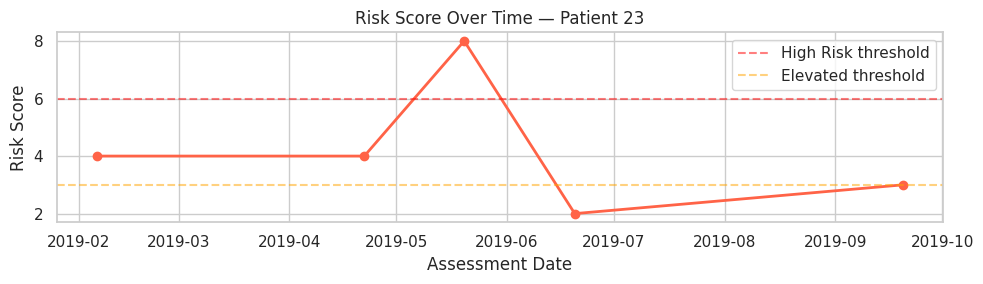



=== REPORT FOR A DEHYDRATED PATIENT ===
PATIENT RISK REPORT — ID: 7210
Total assessments: 2
Date range: 2019-02-20 to 2019-03-22
Overall trend: WORSENING

Latest assessment: 2019-03-22
  Risk score:    13
  Risk category: HIGH RISK
  Keywords:      urine, pain, fever, dry, intake, fluid, diarrhea, wound
  Medications:   16
  Polypharmacy:  Yes

Risk score over time:
  2019-02-20 | Score: 10 | ██████████ | HIGH RISK
  2019-03-22 | Score: 13 | █████████████ | HIGH RISK


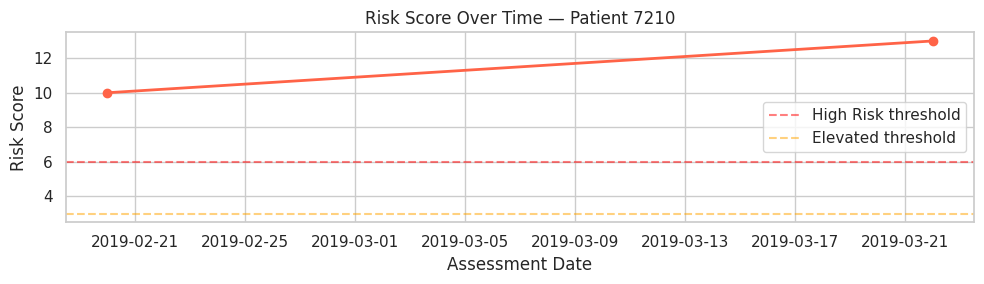

In [ ]:
# ── CELL 20: Sample patient lookup ───────────────────────────

def patient_report(patient_id):
    """Print a full risk report for a single patient."""
    patient_data = master[master["resident_id"] == patient_id].sort_values("date_of_target")

    if len(patient_data) == 0:
        print(f"Patient {patient_id} not found.")
        return

    print("=" * 60)
    print(f"PATIENT RISK REPORT — ID: {patient_id}")
    print("=" * 60)
    print(f"Total assessments: {len(patient_data)}")
    print(f"Date range: {patient_data['date_of_target'].min().date()} to {patient_data['date_of_target'].max().date()}")

    trend = patient_trends[patient_trends["resident_id"]==patient_id]["trend"].values
    print(f"Overall trend: {trend[0] if len(trend) > 0 else 'N/A'}")

    print(f"\nLatest assessment: {patient_data.iloc[-1]['date_of_target'].date()}")
    print(f"  Risk score:    {patient_data.iloc[-1]['final_risk_score']}")
    print(f"  Risk category: {patient_data.iloc[-1]['final_risk_category']}")
    print(f"  Keywords:      {patient_data.iloc[-1]['risk_keywords']}")
    print(f"  Medications:   {int(patient_data.iloc[-1]['num_medications']) if pd.notna(patient_data.iloc[-1]['num_medications']) else 'N/A'}")
    print(f"  Polypharmacy:  {'Yes' if patient_data.iloc[-1]['polypharmacy_flag'] == 1 else 'No'}")

    if pd.notna(patient_data.iloc[-1]['diagnoses']):
        print(f"  Diagnoses:     {patient_data.iloc[-1]['diagnoses'][:150]}...")

    print(f"\nRisk score over time:")
    for _, row in patient_data.iterrows():
        bar = "█" * int(row["final_risk_score"])
        print(f"  {row['date_of_target'].date()} | Score: {int(row['final_risk_score']):2d} | {bar} | {row['final_risk_category']}")

    # Plot timeline
    plt.figure(figsize=(10, 3))
    plt.plot(patient_data["date_of_target"], patient_data["final_risk_score"],
             marker="o", color="tomato", linewidth=2)
    plt.axhline(y=6, color="red",    linestyle="--", alpha=0.5, label="High Risk threshold")
    plt.axhline(y=3, color="orange", linestyle="--", alpha=0.5, label="Elevated threshold")
    plt.title(f"Risk Score Over Time — Patient {patient_id}")
    plt.xlabel("Assessment Date")
    plt.ylabel("Risk Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plot_patient_{patient_id}_timeline.png", dpi=150)
    plt.show()

# Run report for a sample patient with multiple assessments
sample_patients = master.groupby("resident_id").size()
sample_id = sample_patients[sample_patients >= 4].index[0]
patient_report(sample_id)

# Also run for a dehydrated patient
print("\n\n=== REPORT FOR A DEHYDRATED PATIENT ===")
dehyd_id = 7210
patient_report(dehyd_id)



In [ ]:
# ── CELL 21: Save master risk table ─────────────────────────

master_export = master[[
    "resident_id","date_of_target","final_risk_score","final_risk_category",
    "risk_keywords","num_medications","polypharmacy_flag","diagnoses","full_note"
]].copy()
master_export["date_of_target"] = master_export["date_of_target"].dt.date
master_export.to_csv("patient_risk_scores.csv", index=False)
print(f"Saved patient_risk_scores.csv — {len(master_export)} rows")
print("\nTop 10 highest risk assessments:")
print(master_export.nlargest(10, "final_risk_score")[
    ["resident_id","date_of_target","final_risk_score","final_risk_category","risk_keywords"]
].to_string())


In [ ]:
master_export = master.merge(patient_trends, on='resident_id', how='left')
master_export['date_of_target'] = master_export['date_of_target'].dt.strftime('%Y-%m-%d')
master_export.to_csv('patient_risk_scores_full.csv', index=False)

# Download it
from google.colab import files
files.download('patient_risk_scores_full.csv')

# PATIENT RISK STRATIFICATION — MODELLING
# Logistic Regression to predict HIGH RISK assessments

In [ ]:
# ── CELL 23: Build feature table ────────────────────────────
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Use master dataframe already built in previous cells
# master contains: resident_id, date_of_target, risk_score, final_risk_score,
#                  final_risk_category, risk_keywords, num_medications,
#                  polypharmacy_flag, diagnoses, trend, full_note

# --- Build features ---

# 1. Number of risk keywords found
master["num_risk_keywords"] = master["risk_keywords"].apply(
    lambda x: len(x.split(",")) if x != "none" else 0
)

# 2. Binary keyword flags
master["has_dehydration_kw"] = master["risk_keywords"].str.contains(
    "dehydrat|urine", case=False, na=False).astype(int)
master["has_refusal_kw"] = master["risk_keywords"].str.contains(
    "refused", case=False, na=False).astype(int)
master["has_fall_kw"] = master["risk_keywords"].str.contains(
    "fall|fell", case=False, na=False).astype(int)

# 3. Number of diagnoses per patient
diag_counts = diag.groupby("resident_id")["diagnosis"].nunique().reset_index()
diag_counts.columns = ["resident_id", "num_diagnoses"]
master = master.merge(diag_counts, on="resident_id", how="left")
master["num_diagnoses"] = master["num_diagnoses"].fillna(0).astype(int)

# 4. Prior risk score (previous assessment's score for same patient)
master = master.sort_values(["resident_id", "date_of_target"])
master["prior_risk_score"] = master.groupby("resident_id")["final_risk_score"].shift(1).fillna(0)

# 5. Target variable: HIGH RISK = 1, everything else = 0
master["high_risk_flag"] = (master["final_risk_category"] == "HIGH RISK").astype(int)

print("=== FEATURE TABLE ===")
feature_cols = [
    "num_risk_keywords", "polypharmacy_flag", "num_medications",
    "num_diagnoses", "has_dehydration_kw", "has_refusal_kw",
    "has_fall_kw", "prior_risk_score"
]
print(master[feature_cols + ["high_risk_flag"]].describe())
print(f"\nHIGH RISK assessments: {master['high_risk_flag'].sum()} ({master['high_risk_flag'].mean()*100:.1f}%)")


In [ ]:
# ── CELL 24: Train/test split ────────────────────────────────
X = master[feature_cols].copy()
y = master["high_risk_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {len(X_train)} assessments")
print(f"Test set:     {len(X_test)} assessments")
print(f"\nHIGH RISK in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"HIGH RISK in test:     {y_test.sum()} ({y_test.mean()*100:.1f}%)")


In [ ]:
# ── CELL 25: Baseline model ──────────────────────────────────
# Baseline: predict HIGH RISK for all patients with polypharmacy
baseline_preds = X_test["polypharmacy_flag"].values

print("=== BASELINE MODEL (polypharmacy flag only) ===")
print(classification_report(y_test, baseline_preds,
      target_names=["Not High Risk", "High Risk"]))
print(f"Baseline F1 (HIGH RISK): {f1_score(y_test, baseline_preds):.3f}")



In [ ]:
# ── CELL 26: Logistic Regression ────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print("=== LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, lr_preds,
      target_names=["Not High Risk", "High Risk"]))
print(f"F1 Score (HIGH RISK): {f1_score(y_test, lr_preds):.3f}")
print(f"AUC-ROC:              {roc_auc_score(y_test, lr_probs):.3f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds,
    display_labels=["Not High Risk", "High Risk"],
    cmap="Blues", ax=ax
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig("plot_lr_confusion_matrix.png", dpi=150)
plt.show()


=== LOGISTIC REGRESSION COEFFICIENTS ===
           Feature  Coefficient
 num_risk_keywords     4.923819
has_dehydration_kw     1.320601
 polypharmacy_flag     1.306535
    has_refusal_kw     0.670791
       has_fall_kw     0.657845
  prior_risk_score     0.199121
     num_diagnoses     0.056885
   num_medications    -0.121549

→ Positive = increases HIGH RISK probability
→ Negative = decreases HIGH RISK probability


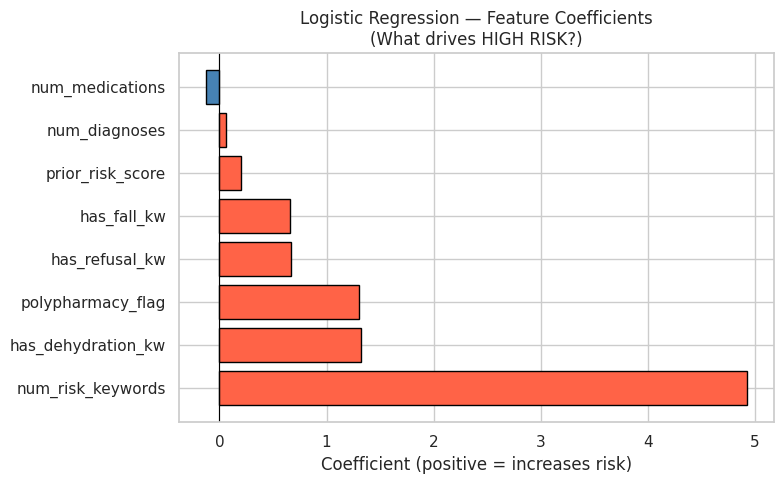

In [ ]:
# ── CELL 27: Feature importance (LR coefficients) ───────────
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\n=== LOGISTIC REGRESSION COEFFICIENTS ===")
print(coef_df.to_string(index=False))
print("\n→ Positive = increases HIGH RISK probability")
print("→ Negative = decreases HIGH RISK probability")

plt.figure(figsize=(8, 5))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Logistic Regression — Feature Coefficients\n(What drives HIGH RISK?)")
plt.xlabel("Coefficient (positive = increases risk)")
plt.tight_layout()
plt.savefig("plot_lr_coefficients.png", dpi=150)
plt.show()

In [ ]:
# ── CELL 28: Random Forest (alternative model) ───────────────
rf = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight="balanced", max_depth=6
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST RESULTS ===")
print(classification_report(y_test, rf_preds,
      target_names=["Not High Risk", "High Risk"]))
print(f"F1 Score (HIGH RISK): {f1_score(y_test, rf_preds):.3f}")
print(f"AUC-ROC:              {roc_auc_score(y_test, rf_probs):.3f}")

# Feature importance
fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(fi_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"], fi_df["Importance"], color="teal", edgecolor="black")
plt.title("Random Forest — Feature Importance\n(What drives HIGH RISK?)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_rf_importance.png", dpi=150)
plt.show()

=== MODEL COMPARISON ===
                  Model  F1 Score  AUC-ROC
Baseline (Polypharmacy)     0.593    0.622
    Logistic Regression     0.903    0.985
          Random Forest     0.887    0.981


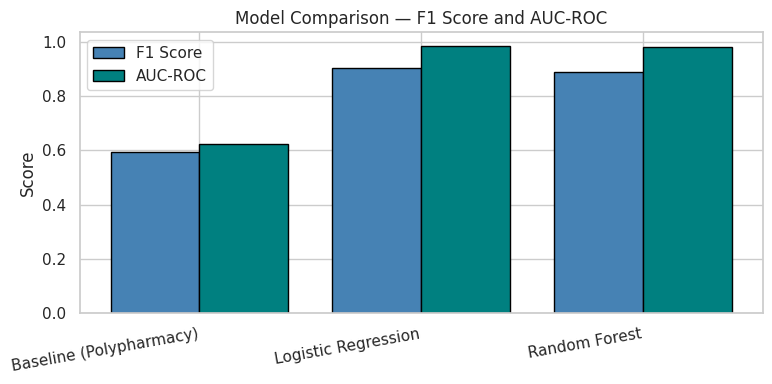

In [ ]:
# ── CELL 29: Model comparison ────────────────────────────────
print("=== MODEL COMPARISON ===")
comparison = pd.DataFrame({
    "Model": ["Baseline (Polypharmacy)", "Logistic Regression", "Random Forest"],
    "F1 Score": [
        round(f1_score(y_test, baseline_preds), 3),
        round(f1_score(y_test, lr_preds), 3),
        round(f1_score(y_test, rf_preds), 3)
    ],
    "AUC-ROC": [
        round(roc_auc_score(y_test, X_test["polypharmacy_flag"]), 3),
        round(roc_auc_score(y_test, lr_probs), 3),
        round(roc_auc_score(y_test, rf_probs), 3)
    ]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 4))
x = range(len(comparison))
plt.bar([i - 0.2 for i in x], comparison["F1 Score"],
        width=0.4, label="F1 Score", color="steelblue", edgecolor="black")
plt.bar([i + 0.2 for i in x], comparison["AUC-ROC"],
        width=0.4, label="AUC-ROC", color="teal", edgecolor="black")
plt.xticks(list(x), comparison["Model"], rotation=10, ha="right")
plt.title("Model Comparison — F1 Score and AUC-ROC")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150)
plt.show()

In [ ]:
print("=== INSUFFICIENT DATA PATIENTS ===")

# Merge patient trends into master dataframe
master = master.merge(patient_trends, on="resident_id", how="left")

insufficient = master[master["trend"] == "INSUFFICIENT DATA"]
sufficient    = master[master["trend"] != "INSUFFICIENT DATA"]

print(f"Patients with insufficient data: {insufficient['resident_id'].nunique()}")
print(f"\nInsufficient data — avg risk score:    {insufficient['final_risk_score'].mean():.2f}")
print(f"Sufficient data   — avg risk score:    {sufficient['final_risk_score'].mean():.2f}")
print(f"\nInsufficient data — HIGH RISK rate:    {(insufficient['final_risk_category']=='HIGH RISK').mean()*100:.1f}%")
print(f"Sufficient data   — HIGH RISK rate:    {(sufficient['final_risk_category']=='HIGH RISK').mean()*100:.1f}%")
print(f"\nInsufficient data — polypharmacy rate: {insufficient['polypharmacy_flag'].mean()*100:.1f}%")
print(f"Sufficient data   — polypharmacy rate: {sufficient['polypharmacy_flag'].mean()*100:.1f}%")
print("\n→ If HIGH RISK rate is similar, insufficient data patients should be included in analysis.")
print("→ If significantly different, they represent a distinct patient group worth noting.")